In [3]:
import sys

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

  Using cached pip-26.1.1-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/122.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/122.9 MB 6.6 MB/s eta 0:00:19
    --------------------------------------- 1.6/122.9 MB 6.4 MB/s eta 0:00:19
    --------------------------------------- 2.4/122.9 MB 5.1 MB/s eta 0:00:24
    --------------------------------------- 2.4/122.9 MB 5.1 MB/s eta 0:00:24
    --------------------------------------- 2.4/122.9 MB 5.1 MB/s eta 0:00:24
   - -------------------------------------- 4.5/122.9 MB 3.9 MB/s eta 0:00:31
   - -------------------------------------- 5.5/122.9 MB 3.9 MB/s eta 0:00:30
   -- ------------------------------------- 7.1/122.9 MB 4.4 MB/s eta 0:00:27


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [6]:
def compute_features(x1, m1, x2, m2, l=1.0):
    """
    Прямая задача для упрощённой постановки.

    Вход:
        x1, m1 — координата и масса первой точки на ребре e1
        x2, m2 — координата и масса второй точки на ребре e2
        l      — длина каждой нити, в работе берём l = 1

    Выход:
        X — входной вектор нейросети из 11 признаков
        Y — истинный вектор параметров: (x1, m1, x2, m2)
    """

    if not (0 < x1 < l):
        raise ValueError("x1 должен быть внутри интервала (0, l)")
    if not (0 < x2 < l):
        raise ValueError("x2 должен быть внутри интервала (0, l)")
    if not (m1 > 0 and m2 > 0):
        raise ValueError("Массы должны быть положительными")

    # Коэффициенты из вывода прямой задачи
    a1 = 1.0 / x1
    a2 = 1.0 / x2
    a3 = 1.0 / l

    b1 = 1.0 / (l - x1)
    b2 = 1.0 / (l - x2)

    S = a1 + a2 + a3

    # Матрица жёсткости после исключения безмассовой вершины V0
    K = np.array([
        [a1 + b1 - (a1 * a1) / S, -(a1 * a2) / S],
        [-(a1 * a2) / S, a2 + b2 - (a2 * a2) / S]
    ], dtype=np.float64)

    # Матрица масс диагональная: M = diag(m1, m2)
    inv_sqrt_M = np.diag([1.0 / np.sqrt(m1), 1.0 / np.sqrt(m2)])

    # Переход к симметричной задаче:
    # M^{-1/2} K M^{-1/2} q = lambda q
    C = inv_sqrt_M @ K @ inv_sqrt_M

    lambdas, q_vectors = np.linalg.eigh(C)

    # Сортируем собственные значения по возрастанию
    idx = np.argsort(lambdas)
    lambdas = lambdas[idx]
    q_vectors = q_vectors[:, idx]

    if np.any(lambdas <= 0):
        raise ValueError("Получены неположительные собственные значения")

    omega1 = np.sqrt(lambdas[0])
    omega2 = np.sqrt(lambdas[1])

    lambda1 = lambdas[0]
    lambda2 = lambdas[1]

    # Собственные формы в координатах A1, A2
    A_vectors = inv_sqrt_M @ q_vectors

    theta_all = []

    for k in range(2):
        A1 = A_vectors[0, k]
        A2 = A_vectors[1, k]

        # Амплитуда в центральной вершине V0
        A0 = (a1 * A1 + a2 * A2) / S

        # Углы малых наклонов считаем пропорциональными наклонам участков у границ
        theta1 = -b1 * A1
        theta2 = -b2 * A2
        theta3 = -a3 * A0

        theta = np.array([theta1, theta2, theta3], dtype=np.float64)

        # Нормировка, чтобы форма не зависела от масштаба амплитуды
        theta = theta / np.linalg.norm(theta)

        # Исправляем произвольный знак собственной формы
        main_index = np.argmax(np.abs(theta))
        if theta[main_index] < 0:
            theta = -theta

        theta_all.extend(theta.tolist())

    X = np.array([
        omega1,
        omega2,
        lambda1,
        lambda2,
        omega2 / omega1,
        theta_all[0],
        theta_all[1],
        theta_all[2],
        theta_all[3],
        theta_all[4],
        theta_all[5]
    ], dtype=np.float64)

    Y = np.array([x1, m1, x2, m2], dtype=np.float64)

    return X, Y

In [7]:
X_example, Y_example = compute_features(
    x1=0.30,
    m1=2.00,
    x2=0.70,
    m2=3.00,
    l=1.0
)

print("X =", X_example)
print("Размер X:", X_example.shape)

print("Y =", Y_example)
print("Размер Y:", Y_example.shape)

X = [ 1.05099363  1.3346967   1.10458761  1.78141528  1.26993795  0.47701845
  0.84086998  0.25571681 -0.43424416  0.89413403 -0.1093451 ]
Размер X: (11,)
Y = [0.3 2.  0.7 3. ]
Размер Y: (4,)


In [8]:
def generate_dataset(
    n_samples=10000,
    l=1.0,
    eps=0.05,
    m_min=0.1,
    m_max=5.0,
    noise_level=0.00,
    random_state=42
):
    """
    Генерация синтетической обучающей выборки.

    n_samples   — число объектов
    l           — длина нити
    eps         — отступ от концов нити, чтобы не брать x слишком близко к 0 и l
    m_min       — минимальная масса
    m_max       — максимальная масса
    noise_level — уровень шума в признаках X
    """

    rng = np.random.default_rng(random_state)

    X_list = []
    Y_list = []

    bad_count = 0

    for _ in range(n_samples):
        x1 = rng.uniform(eps, l - eps)
        x2 = rng.uniform(eps, l - eps)

        m1 = rng.uniform(m_min, m_max)
        m2 = rng.uniform(m_min, m_max)

        try:
            X, Y = compute_features(x1, m1, x2, m2, l=l)

            if noise_level > 0:
                X_noisy = X.copy()

                # Малый относительный шум на спектральные признаки
                X_noisy[:5] = X_noisy[:5] * (1.0 + rng.normal(0.0, noise_level, size=5))

                # Малый аддитивный шум на углы
                X_noisy[5:] = X_noisy[5:] + rng.normal(0.0, noise_level, size=6)

                X = X_noisy

            X_list.append(X)
            Y_list.append(Y)

        except Exception:
            bad_count += 1

    X_array = np.array(X_list, dtype=np.float32)
    Y_array = np.array(Y_list, dtype=np.float32)

    return X_array, Y_array, bad_count


X, Y, bad_count = generate_dataset(
    n_samples=10000,
    l=1.0,
    eps=0.05,
    m_min=0.1,
    m_max=5.0,
    noise_level=0.00,
    random_state=42
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Плохих объектов:", bad_count)

X shape: (10000, 11)
Y shape: (10000, 4)
Плохих объектов: 0


In [9]:
feature_names = [
    "omega1",
    "omega2",
    "lambda1",
    "lambda2",
    "omega2_div_omega1",
    "theta1_mode1",
    "theta2_mode1",
    "theta3_mode1",
    "theta1_mode2",
    "theta2_mode2",
    "theta3_mode2"
]

target_names = [
    "x1",
    "m1",
    "x2",
    "m2"
]

df_X = pd.DataFrame(X, columns=feature_names)
df_Y = pd.DataFrame(Y, columns=target_names)

df = pd.concat([df_X, df_Y], axis=1)

df.head()

,omega1,omega2,lambda1,lambda2,omega2_div_omega1,theta1_mode1,theta2_mode1,theta3_mode1,theta1_mode2,theta2_mode2,theta3_mode2,x1,m1,x2,m2
0,0.873031,1.101028,0.762183,1.212263,1.261156,0.645446,0.723603,0.244536,0.974959,-0.222074,0.011772,0.746560,4.307130,0.444991,3.517103
1,0.842775,1.942854,0.710269,3.774681,2.305307,0.678468,0.570127,0.463289,-0.005994,0.999974,0.004109,0.134760,3.829585,0.928060,3.951715
2,0.745826,1.384221,0.556256,1.916069,1.855957,0.368895,0.874603,0.314621,0.841951,-0.344488,0.415266,0.165302,1.916910,0.455347,4.641149
3,1.251482,2.160029,1.566208,4.665726,1.725977,0.957730,0.237301,0.162607,-0.042180,0.997176,0.062141,0.629479,2.272730,0.790485,1.213470
4,0.760818,1.164283,0.578843,1.355555,1.530305,0.843546,0.414750,0.341193,0.787796,-0.531724,-0.310881,0.549126,4.155393,0.107436,3.195156


In [10]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=SEED
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=SEED
)

print("Train:", X_train.shape, Y_train.shape)
print("Val:  ", X_val.shape, Y_val.shape)
print("Test: ", X_test.shape, Y_test.shape)

Train: (7000, 11) (7000, 4)
Val:   (1500, 11) (1500, 4)
Test:  (1500, 11) (1500, 4)


In [11]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = x_scaler.transform(X_val).astype(np.float32)
X_test_scaled = x_scaler.transform(X_test).astype(np.float32)

Y_train_scaled = y_scaler.fit_transform(Y_train).astype(np.float32)
Y_val_scaled = y_scaler.transform(Y_val).astype(np.float32)
Y_test_scaled = y_scaler.transform(Y_test).astype(np.float32)

print("Среднее X_train_scaled:", X_train_scaled.mean(axis=0).round(3))
print("Стандартное отклонение X_train_scaled:", X_train_scaled.std(axis=0).round(3))

Среднее X_train_scaled: [-0.  0.  0. -0. -0. -0.  0. -0.  0.  0.  0.]
Стандартное отклонение X_train_scaled: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [12]:
batch_size = 128

train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(Y_train_scaled, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(X_val_scaled, dtype=torch.float32),
    torch.tensor(Y_val_scaled, dtype=torch.float32)
)

test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(Y_test_scaled, dtype=torch.float32)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [13]:
class PhysicsRegressionNet(nn.Module):
    def __init__(self, input_size=11, output_size=4):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, output_size)
        )

    def forward(self, x):
        return self.net(x)


model = PhysicsRegressionNet(input_size=11, output_size=4).to(device)

model

PhysicsRegressionNet(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=128, out_features=64, bias=True)
    (12): ReLU()
    (13): Linear(in_features=64, out_features=4, bias=True)
  )
)

In [14]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=150,
    learning_rate=0.001,
    weight_decay=0.0001,
    patience=20
):
    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(1, epochs + 1):
        model.train()

        train_loss_sum = 0.0
        train_count = 0

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(X_batch)
            loss = criterion(predictions, Y_batch)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * X_batch.size(0)
            train_count += X_batch.size(0)

        train_loss = train_loss_sum / train_count

        model.eval()

        val_loss_sum = 0.0
        val_count = 0

        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)

                predictions = model(X_batch)
                loss = criterion(predictions, Y_batch)

                val_loss_sum += loss.item() * X_batch.size(0)
                val_count += X_batch.size(0)

        val_loss = val_loss_sum / val_count

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss = {train_loss:.6f} | "
                f"val_loss = {val_loss:.6f}"
            )

        if patience_counter >= patience:
            print(f"Early stopping на эпохе {epoch}")
            break

    model.load_state_dict(best_model_state)

    return model, history

In [15]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=150,
    learning_rate=0.001,
    weight_decay=0.0001,
    patience=20
)

Epoch 001 | train_loss = 0.283842 | val_loss = 0.070787
Epoch 010 | train_loss = 0.057013 | val_loss = 0.024993
Epoch 020 | train_loss = 0.046576 | val_loss = 0.019787
Epoch 030 | train_loss = 0.036767 | val_loss = 0.011373
Epoch 040 | train_loss = 0.034415 | val_loss = 0.012253
Epoch 050 | train_loss = 0.031746 | val_loss = 0.009732
Epoch 060 | train_loss = 0.030880 | val_loss = 0.009679
Epoch 070 | train_loss = 0.027718 | val_loss = 0.010301
Epoch 080 | train_loss = 0.028098 | val_loss = 0.008094
Early stopping на эпохе 82


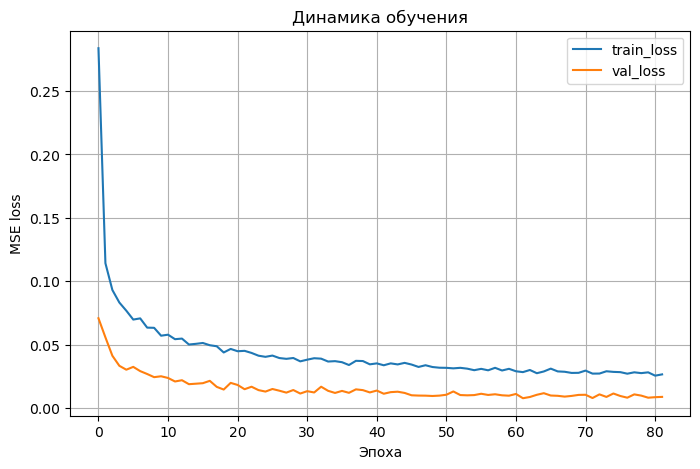

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("Динамика обучения")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
def predict_scaled(model, X_scaled):
    model.eval()

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

    with torch.no_grad():
        predictions_scaled = model(X_tensor).cpu().numpy()

    return predictions_scaled


Y_pred_test_scaled = predict_scaled(model, X_test_scaled)

# Возвращаем предсказания из нормированного масштаба в физический
Y_pred_test = y_scaler.inverse_transform(Y_pred_test_scaled)

# Дополнительная физическая постобработка
Y_pred_test[:, 0] = np.clip(Y_pred_test[:, 0], 0.05, 0.95)
Y_pred_test[:, 1] = np.clip(Y_pred_test[:, 1], 0.1, 5.0)
Y_pred_test[:, 2] = np.clip(Y_pred_test[:, 2], 0.05, 0.95)
Y_pred_test[:, 3] = np.clip(Y_pred_test[:, 3], 0.1, 5.0)

Y_true_test = Y_test.copy()

Y_pred_test[:5]

array([[0.05595518, 4.686072  , 0.23540996, 4.0963836 ],
       [0.31289774, 3.7007854 , 0.8573711 , 3.2977507 ],
       [0.88941276, 4.1978827 , 0.46235785, 3.9594808 ],
       [0.35048297, 3.9297383 , 0.8754511 , 1.6791613 ],
       [0.32668608, 1.9799235 , 0.62801766, 2.042355  ]], dtype=float32)

In [18]:
mse_total = mean_squared_error(Y_true_test, Y_pred_test)
mae_total = mean_absolute_error(Y_true_test, Y_pred_test)

mse_by_target = mean_squared_error(
    Y_true_test,
    Y_pred_test,
    multioutput="raw_values"
)

mae_by_target = mean_absolute_error(
    Y_true_test,
    Y_pred_test,
    multioutput="raw_values"
)

print("Общий MSE:", mse_total)
print("Общий MAE:", mae_total)

metrics_df = pd.DataFrame({
    "Параметр": target_names,
    "MSE": mse_by_target,
    "MAE": mae_by_target
})

metrics_df

Общий MSE: 0.013704633340239525
Общий MAE: 0.05566537752747536


,Параметр,MSE,MAE
0,x1,0.000281,0.011809
1,m1,0.028154,0.102189
2,x2,0.000247,0.011981
3,m2,0.026136,0.096683


In [19]:
comparison_df = pd.DataFrame({
    "x1_true": Y_true_test[:, 0],
    "x1_pred": Y_pred_test[:, 0],

    "m1_true": Y_true_test[:, 1],
    "m1_pred": Y_pred_test[:, 1],

    "x2_true": Y_true_test[:, 2],
    "x2_pred": Y_pred_test[:, 2],

    "m2_true": Y_true_test[:, 3],
    "m2_pred": Y_pred_test[:, 3],
})

comparison_df.head(20)

,x1_true,x1_pred,m1_true,m1_pred,x2_true,x2_pred,m2_true,m2_pred
0,0.077202,0.055955,4.694882,4.686072,0.207871,0.235410,4.099820,4.096384
1,0.314439,0.312898,3.760723,3.700785,0.855994,0.857371,3.125715,3.297751
2,0.903015,0.889413,4.535833,4.197883,0.451310,0.462358,3.962055,3.959481
3,0.350274,0.350483,3.836407,3.929738,0.858530,0.875451,1.425621,1.679161
4,0.323091,0.326686,1.889554,1.979923,0.619135,0.628018,2.007446,2.042355
5,0.223040,0.208621,0.418516,0.435910,0.299691,0.328702,3.248772,3.177909
6,0.653817,0.622104,0.533245,0.586075,0.259287,0.267750,4.890839,4.825450
7,0.215466,0.215868,0.541540,0.711137,0.410754,0.411940,0.120808,0.148187
8,0.498953,0.505152,3.970214,4.007115,0.197747,0.200673,4.056152,4.135814
9,0.151445,0.146842,4.849217,4.750931,0.142167,0.143643,3.416890,3.503435


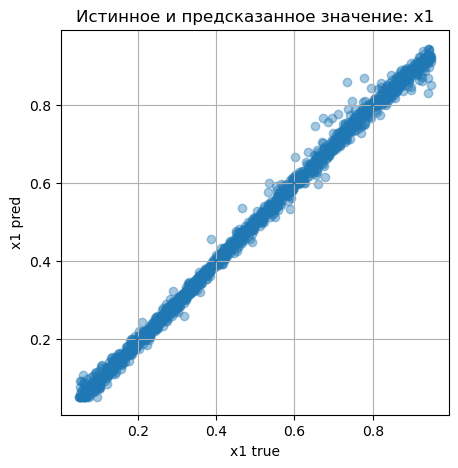

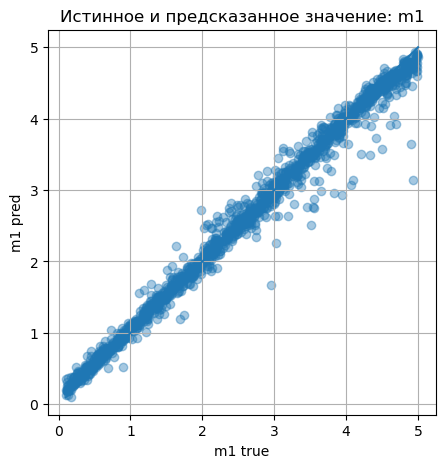

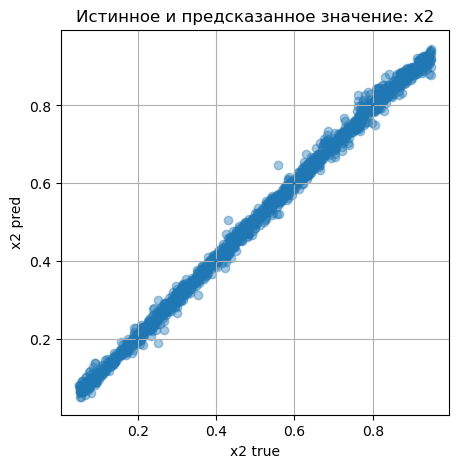

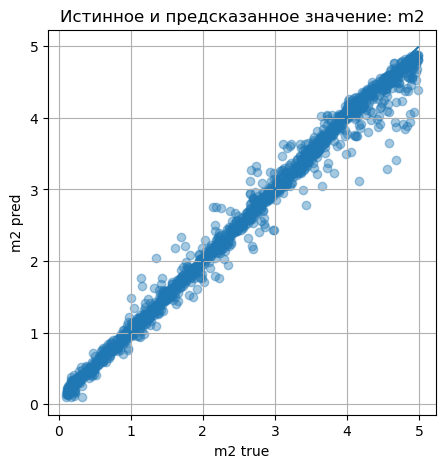

In [20]:
for i, name in enumerate(target_names):
    plt.figure(figsize=(5, 5))
    plt.scatter(Y_true_test[:, i], Y_pred_test[:, i], alpha=0.4)

    min_value = min(Y_true_test[:, i].min(), Y_pred_test[:, i].min())
    max_value = max(Y_true_test[:, i].max(), Y_pred_test[:, i].max())

    plt.plot([min_value, max_value], [min_value, max_value])
    plt.xlabel(f"{name} true")
    plt.ylabel(f"{name} pred")
    plt.title(f"Истинное и предсказанное значение: {name}")
    plt.grid(True)
    plt.show()

In [21]:
import pickle

torch.save(model.state_dict(), "physics_regression_net.pt")

with open("x_scaler.pkl", "wb") as file:
    pickle.dump(x_scaler, file)

with open("y_scaler.pkl", "wb") as file:
    pickle.dump(y_scaler, file)

print("Модель сохранена в physics_regression_net.pt")
print("Нормировщик X сохранён в x_scaler.pkl")
print("Нормировщик Y сохранён в y_scaler.pkl")

Модель сохранена в physics_regression_net.pt
Нормировщик X сохранён в x_scaler.pkl
Нормировщик Y сохранён в y_scaler.pkl


In [22]:
range_x = 0.95 - 0.05
range_m = 5.0 - 0.1

normalized_mae = np.array([
    mae_by_target[0] / range_x * 100,
    mae_by_target[1] / range_m * 100,
    mae_by_target[2] / range_x * 100,
    mae_by_target[3] / range_m * 100
])

extended_metrics_df = pd.DataFrame({
    "Параметр": target_names,
    "MSE": mse_by_target,
    "MAE": mae_by_target,
    "MAE, % от диапазона": normalized_mae
})

extended_metrics_df

,Параметр,MSE,MAE,"MAE, % от диапазона"
0,x1,0.000281,0.011809,1.312087
1,m1,0.028154,0.102189,2.085488
2,x2,0.000247,0.011981,1.331251
3,m2,0.026136,0.096683,1.973113


In [23]:
mass_error_df = pd.DataFrame({
    "m1_true": Y_true_test[:, 1],
    "m1_pred": Y_pred_test[:, 1],
    "m1_error": Y_pred_test[:, 1] - Y_true_test[:, 1],
    "m2_true": Y_true_test[:, 3],
    "m2_pred": Y_pred_test[:, 3],
    "m2_error": Y_pred_test[:, 3] - Y_true_test[:, 3],
})

mass_error_df.head()

,m1_true,m1_pred,m1_error,m2_true,m2_pred,m2_error
0,4.694882,4.686072,-0.008810,4.099820,4.096384,-0.003436
1,3.760723,3.700785,-0.059938,3.125715,3.297751,0.172035
2,4.535833,4.197883,-0.337951,3.962055,3.959481,-0.002574
3,3.836407,3.929738,0.093331,1.425621,1.679161,0.253540
4,1.889554,1.979923,0.090369,2.007446,2.042355,0.034909


In [24]:
def make_bins_report(true_values, pred_values, parameter_name):
    errors = pred_values - true_values

    bins = [0.1, 1.0, 2.0, 3.0, 4.0, 5.0]
    bin_labels = ["0.1-1.0", "1.0-2.0", "2.0-3.0", "3.0-4.0", "4.0-5.0"]

    temp_df = pd.DataFrame({
        "true": true_values,
        "pred": pred_values,
        "error": errors,
        "abs_error": np.abs(errors)
    })

    temp_df["bin"] = pd.cut(
        temp_df["true"],
        bins=bins,
        labels=bin_labels,
        include_lowest=True
    )

    report = temp_df.groupby("bin").agg(
        count=("true", "count"),
        mean_true=("true", "mean"),
        mean_pred=("pred", "mean"),
        mean_error=("error", "mean"),
        mae=("abs_error", "mean")
    ).reset_index()

    report.insert(0, "parameter", parameter_name)

    return report


m1_bins_report = make_bins_report(
    Y_true_test[:, 1],
    Y_pred_test[:, 1],
    "m1"
)

m2_bins_report = make_bins_report(
    Y_true_test[:, 3],
    Y_pred_test[:, 3],
    "m2"
)

mass_bins_report = pd.concat(
    [m1_bins_report, m2_bins_report],
    axis=0
)

mass_bins_report

C:\TEMP\ipykernel_1328\1161698618.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = temp_df.groupby("bin").agg(
C:\TEMP\ipykernel_1328\1161698618.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = temp_df.groupby("bin").agg(


,parameter,bin,count,mean_true,mean_pred,mean_error,mae
0,m1,0.1-1.0,257,0.570338,0.648969,0.078630,0.087157
1,m1,1.0-2.0,285,1.495921,1.538566,0.042645,0.082123
2,m1,2.0-3.0,320,2.508557,2.526122,0.017565,0.096233
3,m1,3.0-4.0,320,3.527115,3.498056,-0.029059,0.113047
4,m1,4.0-5.0,318,4.510274,4.409559,-0.100715,0.127387
0,m2,0.1-1.0,258,0.517322,0.566602,0.049281,0.068707
1,m2,1.0-2.0,310,1.482850,1.509196,0.026347,0.076708
2,m2,2.0-3.0,290,2.531741,2.540744,0.009003,0.092164
3,m2,3.0-4.0,320,3.514544,3.529854,0.015310,0.088895
4,m2,4.0-5.0,322,4.482000,4.379454,-0.102546,0.150136
